In [1]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

print(stock.head())

/tmp/ipykernel_3699/1613820573.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400505  72.460769  71.156667  71.409770  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
2020-01-07  71.928040  72.533080  71.708680  72.277563  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [3]:
stock['Next_Close'] = stock['Close'].shift(-1)

# Drop last row (it becomes NaN)
stock = stock.dropna()

In [4]:
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [8]:
y_pred = model.predict(X_test)

In [9]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 100.23868042955206


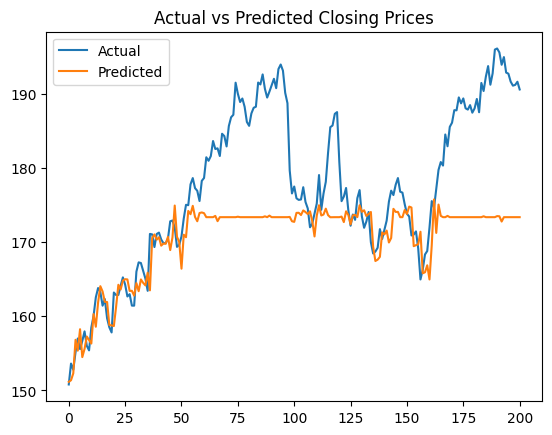

In [10]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()